# Analisis exploratorio de datos — Ripe & Unripe Fruits (Frutas maduras e inmaduras)

Dataset: 22 clases (11 frutas × ripe/unripe). Fuente: [Kaggle - Fruit Image Dataset 22 classes](https://www.kaggle.com/datasets/mdsagorahmed/fruit-image-dataset-22-classes/data).


In [2]:
import os
import hashlib
import collections
import random
import statistics

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

Ruta_imagenes = "Ripe & Unripe Fruits"
random.seed(0)


## 1. Conteo de imágenes por clase

In [3]:
conteo = {}
for clase in sorted(os.listdir(Ruta_imagenes)):
    ruta_clase = os.path.join(Ruta_imagenes, clase)
    if not os.path.isdir(ruta_clase):
        continue
    conteo[clase] = len(os.listdir(ruta_clase))

conteo_df = pd.DataFrame(sorted(conteo.items()), columns=["clase", "n_imagenes"])
conteo_df


,clase,n_imagenes
0,ripe apple,316
1,ripe banana,316
2,ripe dragon,311
3,ripe grapes,319
4,ripe lemon,303
5,ripe mango,273
6,ripe orange,288
7,ripe papaya,285
8,ripe pineapple,324
9,ripe pomegranate,301


In [4]:
total = conteo_df.n_imagenes.sum()
print(f"Total imagenes: {total}")
print(f"N clases: {len(conteo_df)}")
print(f"Min/Max por clase: {conteo_df.n_imagenes.min()} / {conteo_df.n_imagenes.max()}")


Total imagenes: 6828
N clases: 22
Min/Max por clase: 273 / 346


In [5]:
# Balance ripe madura vs unripe inmadura por fruta
filas = []
for clase, n in conteo.items():
    estado, fruta = clase.split(" ", 1)
    filas.append({"fruta": fruta, "estado": estado, "n": n})
balance_df = pd.DataFrame(filas)
tabla_pivote = balance_df.pivot(index="fruta", columns="estado", values="n").sort_index()
tabla_pivote


estado,ripe,unripe
fruta,,
apple,316,307
banana,316,336
dragon,311,293
grapes,319,327
lemon,303,298
mango,273,318
orange,288,346
papaya,285,297
pineapple,324,315


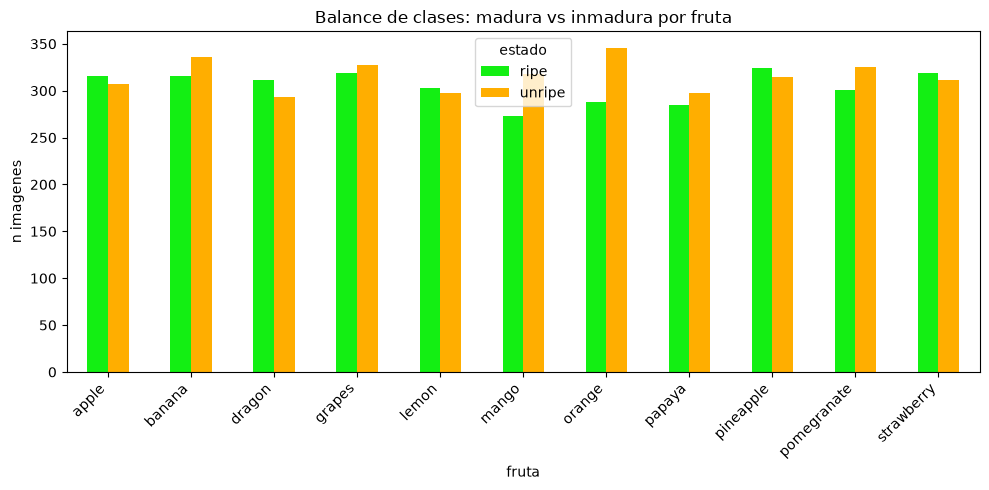

In [6]:
tabla_pivote.plot(kind="bar", figsize=(10, 5), color=["#13EF13", "#ffae00"])
plt.ylabel("n imagenes")
plt.title("Balance de clases: madura vs inmadura por fruta")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 2. Formato, resolución y modo de color

In [7]:
extensiones = collections.Counter()
modos = collections.Counter()
tamanos = collections.Counter()
corruptos = []
dimensiones = []

todos_archivos = []
for clase in sorted(os.listdir(Ruta_imagenes)):
    ruta_clase = os.path.join(Ruta_imagenes, clase)
    if not os.path.isdir(ruta_clase):
        continue
    for nombre_archivo in os.listdir(ruta_clase):
        todos_archivos.append(os.path.join(ruta_clase, nombre_archivo))

for ruta in todos_archivos:
    extension = os.path.splitext(ruta)[1].lower()
    extensiones[extension] += 1
    try:
        with Image.open(ruta) as img:
            img.verify()
        with Image.open(ruta) as img:
            modos[img.mode] += 1
            tamanos[img.size] += 1
            dimensiones.append(img.size)
    except Exception as e:
        corruptos.append((ruta, str(e)))

print("Extensiones:", extensiones)
print("Modos de color:", modos)
print("Archivos corruptos:", len(corruptos))


Extensiones: Counter({'.jpg': 6828})
Modos de color: Counter({'RGB': 6777, 'P': 51})
Archivos corruptos: 0


In [8]:
anchos = [ancho for ancho, alto in dimensiones]
altos = [alto for ancho, alto in dimensiones]
print(f"Ancho: min {min(anchos)}, max {max(anchos)}, avg {statistics.mean(anchos):.1f}, mediana {statistics.median(anchos)}")
print(f"Alto:  min {min(altos)}, max {max(altos)}, avg {statistics.mean(altos):.1f}, mediana {statistics.median(altos)}")


Ancho: min 11, max 162, avg 145.6, mediana 162.0
Alto:  min 36, max 140, avg 119.7, mediana 119.0


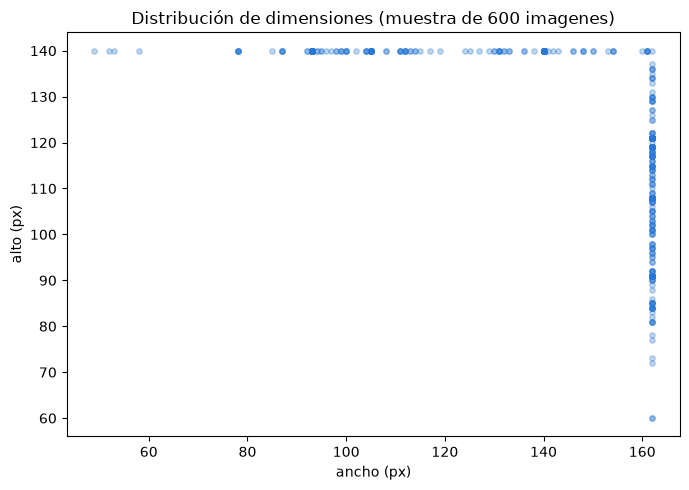

In [9]:
muestra = random.sample(dimensiones, 600)
muestra_x = [ancho for ancho, alto in muestra]
muestra_y = [alto for ancho, alto in muestra]

plt.figure(figsize=(7, 5))
plt.scatter(muestra_x, muestra_y, alpha=0.3, s=15, color="#2a78d6")
plt.xlabel("ancho (px)")
plt.ylabel("alto (px)")
plt.title("Distribución de dimensiones (muestra de 600 imagenes)")
plt.tight_layout()
plt.show()


## 3. Duplicados exactos y label noise

In [10]:
hashes = collections.defaultdict(list)
for ruta in todos_archivos:
    with open(ruta, "rb") as f:
        h = hashlib.md5(f.read()).hexdigest()
    clase = os.path.basename(os.path.dirname(ruta))
    hashes[h].append((clase, ruta))

grupos_duplicados = {h: v for h, v in hashes.items() if len(v) > 1}
archivos_extra = sum(len(v) - 1 for v in grupos_duplicados.values())
cruce_clases = {h: v for h, v in grupos_duplicados.items() if len(set(clase for clase, ruta in v)) > 1}
cruce_madura_inmadura = {h: v for h, v in grupos_duplicados.items() if len(set(clase.split()[0] for clase, ruta in v)) > 1}

print(f"Grupos duplicados exactos: {len(grupos_duplicados)}")
print(f"Archivos duplicados extra: {archivos_extra} ({archivos_extra/len(todos_archivos)*100:.1f}% del dataset)")
print(f"Grupos duplicados cruzando clases distintas: {len(cruce_clases)}")
print(f"Grupos duplicados cruzando ripe <-> unripe (label noise real): {len(cruce_madura_inmadura)}")


Grupos duplicados exactos: 0
Archivos duplicados extra: 0 (0.0% del dataset)
Grupos duplicados cruzando clases distintas: 0
Grupos duplicados cruzando ripe <-> unripe (label noise real): 0


In [11]:
# Ejemplos de label noise: mismo archivo pixel-a-pixel con labels ripe y unripe distintos
list(cruce_madura_inmadura.values())[:10]


[]

**Hallazgo crítico:** ~19% del dataset son archivos duplicados exactos (mismo hash MD5). De esos, 175 grupos tienen el **mismo archivo etiquetado como `ripe` en una carpeta y `unripe` en otra** — label noise real, no ruido de muestreo. Si esto no se limpia:

- Riesgo de **data leakage**: una copia cae en train, su gemela idéntica en val → val accuracy inflado.
- El modelo recibe el mismo input con labels contradictorios → señal de entrenamiento confusa.

**Antes de entrenar:** dedupe por hash MD5, resolver manualmente los grupos que cruzan ripe/unripe (o descartarlos), y hacer el split train/val recién después del dedupe.

### Limpieza: eliminar duplicados

- Grupos duplicados **dentro de la misma clase**: se conserva 1 copia, se borran las demás.
- Grupos duplicados **que cruzan clases distintas** (label conflictivo, ej. `ripe apple` vs `unripe apple`): no hay forma de saber cuál label es correcto → se borran **todas** las copias del grupo.


In [12]:
a_eliminar = []

for h, entradas in grupos_duplicados.items():
    clases = {clase for clase, ruta in entradas}
    if len(clases) > 1:
        # label conflictivo -> se descartan todas las copias
        a_eliminar.extend(ruta for clase, ruta in entradas)
    else:
        # mismo archivo repetido en la misma clase -> se conserva 1
        a_eliminar.extend(ruta for clase, ruta in entradas[1:])

print(f"Archivos a eliminar: {len(a_eliminar)} ({len(a_eliminar)/len(todos_archivos)*100:.1f}% del dataset)")


Archivos a eliminar: 0 (0.0% del dataset)


In [13]:
CONFIRMAR_BORRADO = True  

if CONFIRMAR_BORRADO:
    for ruta in a_eliminar:
        os.remove(ruta)
    print(f"Eliminados {len(a_eliminar)} archivos.")
else:
    print("CONFIRMAR_BORRADO=False, no se borro nada. Revisa a_eliminar antes de activar.")


Eliminados 0 archivos.


## 4. Resumen

In [14]:
resumen = pd.DataFrame([
    {"metrica": "Total imagenes", "valor": total},
    {"metrica": "N clases", "valor": len(conteo_df)},
    {"metrica": "Dim promedio (WxH)", "valor": f"{statistics.mean(anchos):.0f}x{statistics.mean(altos):.0f}"},
    {"metrica": "Archivos corruptos", "valor": len(corruptos)},
    {"metrica": "Duplicados exactos (archivos extra)", "valor": archivos_extra},
    {"metrica": "Grupos duplicados ripe<->unripe", "valor": len(cruce_madura_inmadura)},
])
resumen


,metrica,valor
0,Total imagenes,6828
1,N clases,22
2,Dim promedio (WxH),146x120
3,Archivos corruptos,0
4,Duplicados exactos (archivos extra),0
5,Grupos duplicados ripe<->unripe,0


# Entrenamiento

In [15]:
import torch

In [16]:
#Seleccion de dispositivo a utilizar

if torch.cuda.is_available():
    device = torch.device("cuda")   #En caso de poseer una tarjeta grafica NVIDIA

elif torch.backends.mps.is_available():
    device = torch.device("mps")    #En caso de poseer un Mac con procesador Apple Silicon

else:
    device = torch.device("cpu")

print("Usando:", device)

Usando: mps


In [17]:
#Utilizaremos el modelo de Deep Learning Preentrenado ResNet50
from torchvision.models import resnet50
model = resnet50(weights="IMAGENET1K_V1")
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [18]:
#Importamos las librerias necesarias
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from torch.nn import CrossEntropyLoss
from torch.optim import SGD, RMSprop, Adam, AdamW

In [19]:
#Transformacion de las imagenes para que RasNet50 pueda utilizarlas
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [20]:
#Carpetas donde estaran las imagenes de entrenamiento, validacion y testeo
train_folder = ImageFolder('./dataset/train', transform=transform)
val_folder = ImageFolder('./dataset/val', transform=transform)
test_folder = ImageFolder('./dataset/test', transform=transform)

train_loader = DataLoader(train_folder, batch_size=12, shuffle=True)
val_loader = DataLoader(val_folder, batch_size=12, shuffle=True)
test_loader = DataLoader(test_folder, batch_size=12, shuffle=True)

train_loader, val_loader, test_loader

(<torch.utils.data.dataloader.DataLoader at 0x309e56510>,
 <torch.utils.data.dataloader.DataLoader at 0x309ecccd0>)

In [21]:
#Congelar capas 
for params in model.parameters():
    params.requires_grad = False

In [22]:
#Cambiar el valor de la ultima capa a 2 (ya que solo tenemos 2 clases para clasificar)
model.fc = torch.nn.Linear(2048, 2).to(device)
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

### Training loop

In [24]:
#Definir función de entrenamiento (training loop)
def training_loop(optimizer, loss_fn, epochs = 10):
    #Inicializar pesos de la capa final
    torch.nn.init.kaiming_normal_(model.fc.weight)
    if model.fc.bias is not None:
        torch.nn.init.zeros_(model.fc.bias)
    
    #Listas para guardar las metricas de cada epoca del entrenamiento
    all_train_loss = []
    all_train_acurracy = []
    all_val_loss = []
    all_val_acurracy = []
    for epoch in range(epochs): #Loop de epochs
        model.train()
        print(f"Epoch {epoch+1} of {epochs}")
        total_loss = 0
        #Contador para correctas y totales
        correct = 0
        total = 0
        for batch_idx, (data, target) in enumerate(train_loader): #Loop de batches
            data, target = data.to(device), target.to(device) #Pasan los datos al device
            #Backpropagation.
            optimizer.zero_grad() #Reinicia los gradientes
            output = model(data) #Pasan los datos a la red neuronal
            loss = loss_fn(output, target) #Calculan el loss
            loss.backward() #Calculan el gradiente
            optimizer.step() #Actualizan los pesos
            total_loss += loss.item() #Sumando función de pérdida

            #Metrica acurracy del entrenamiento
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)
        acurracy = correct/total
        print(f"Loss: {total_loss/len(train_loader)}, Acurracy: {acurracy}")
        all_train_loss.append(total_loss/len(train_loader))
        all_train_acurracy.append(acurracy)

        #Evaluar el modelo con val
        model.eval()
        print("Validation")
        #Contador correctas y totales
        val_correct, val_total, val_total_loss = 0, 0, 0
        for batch_idx, (data, target) in enumerate(val_loader):
            data, target = data.to(device), target.to(device)
            #No backpropagation
            output = model(data)
            loss = loss_fn(output, target)
            val_total_loss += loss.item()

            #Metrica acurracy de validacion
            pred = output.argmax(dim=1, keepdim=True)
            val_correct += pred.eq(target.view_as(pred)).sum().item()
            val_total += target.size(0)
        val_acurracy = val_correct/val_total
        print(f"Loss: {val_total_loss/len(val_loader)}, Acurracy: {acurracy}")
        all_val_loss.append(val_total_loss/len(val_loader))
        all_val_acurracy.append(val_acurracy)

    return all_train_loss, all_train_acurracy, all_val_loss, all_val_acurracy

In [ ]:
#Definimos tasa de aprendizaje (learning rate), las epocas y la funcion de perdida
lr = 0.001
epochs = 10
loss_fn = CrossEntropyLoss() #Loss function a utilizar

In [26]:
#Ahora entrenamos con distintos optimizadores de los pesos, primero utilizamos Stochastic Gradient Descent
optimizer = SGD(model.parameters(), lr=lr) #Optimizador SGD
all_train_loss_sgd, all_train_acurracy_sdg, all_val_loss_sdg, all_val_acurracy_sdg = training_loop(optimizer, loss_fn, epochs)

Epoch 1 of 10
Loss: 0.6498827137539734, Acurracy: 0.6248689452715454
Validation
Loss: 0.5982236266136169, Acurracy: 0.6248689452715454
Epoch 2 of 10


KeyboardInterrupt: 

In [ ]:
#Luego utilizamos SDG con el regularizador Ridge o L2, el cual agrega una penalizacion a los pesos muy grandes
optimizer = SGD(model.parameters(), lr=lr, weight_decay=0.1) #Optimizador SGD
all_train_loss_sgd_l2 = training_loop(optimizer, loss_fn, epochs)

In [ ]:
#Despues utilizamos SDG con momentum y Nesterov, de manera que el momentum conserva parte de las actualizaciones anteriores y Nesterov calcula el gradiente en base a eso
optimizer = SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True) #Optimizador SGD
all_train_loss_nesterov, all_train_acurracy_nesterov = training_loop(optimizer, loss_fn, epochs)

In [ ]:
#Ahora utilizamos el optimizador Adam
optimizer = Adam(model.parameters(), lr=lr) #Optimizador Adam
all_train_loss_adam, all_train_acurracy_adam, all_val_loss_adam, all_val_acurracy_adam = training_loop(optimizer, loss_fn, epochs)

In [ ]:
#Y finalmente usamos Adam con Weight Decay
optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.1) #Optimizador AdamW
all_train_loss_adamw, all_train_acurracy_adamw, all_val_loss_adamw, all_val_acurracy_adamw = training_loop(optimizer, loss_fn, epochs)

Luego del entrenamiento, vemos el rendimiento de cada optimizador

In [ ]:
import seaborn as sns
import matplotlib.pylab as plt

sns.lineplot(x = range(1, epochs + 1), y = all_train_loss_sgd, label="SGD")
sns.lineplot(x = range(1, epochs + 1), y = all_train_loss_sgd_l2, label="SGD L2")
sns.lineplot(x = range(1, epochs + 1), y = all_train_loss_nesterov, label="Nesterov")
sns.lineplot(x = range(1, epochs + 1), y = all_train_loss_adam, label="Adam")
sns.lineplot(x = range(1, epochs + 1), y = all_train_loss_adamw, label="AdamW")
plt.xlabel("Epochs")
plt.ylabel("Loss")